# Tree model Empirics

- 일본의 니케이를 예측하는데 미국 지수와 엔/달러 환율이
 예측력을 높힌다는 기존연구를 한국자료로 바꿔서 단순
mimic
  * caution: for class not research results


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import datetime as dt
import sys

try:
    import yfinance as yf
except ModuleNotFoundError:
    !{sys.executable} -m pip install -q yfinance
    import yfinance as yf


In [ ]:
# S&P500: SP500
# KRW/USD: DEXKOUS

In [ ]:
# if 'google.colab' in str(get_ipython):
#   ImagePath = '/gdrive/MyDrive/Python/images/'
#   filePath = '/content/drive/MyDrive/Python/data/'
# elif sys.platform.startswith('win'):
#   ImagePath = 'G:/Python/Images/'
#   filePath = "G:/python/data/"
# else:
#   ImagePath = '/mnt/G/python/Images/'
#   filePath = '/mnt/G/python/data/'

In [ ]:
# KRW = pd.read_csv(filePath+"KRW.csv", index_col='Date', parse_dates=True, thousands=',')
# KRW.head()

,KRW
Date,
1981-04-13,675.40
1981-04-14,676.70
1981-04-15,676.70
1981-04-16,676.70
1981-04-17,676.75


In [ ]:
# KRW['KRW'] = pd.to_numeric(KRW.KRW, errors='coerce')
# KRW = KRW.dropna()

In [ ]:
# KRW.isna().sum()

KRW    0
dtype: int64

In [ ]:
KRW = yf.download('USDKRW=X').Close

[*********************100%%**********************]  1 of 1 completed


In [ ]:
KOSPI = yf.download("^KS11").Close

# kospi = yf.Ticker('^ks11)
# kospi.history()
# kospi.recommendations
# please check dir(kospi) with yfinance
# dir(kospi)--> recent news --> from nltk.__.vader import SentimentIntensityAnalyser

[*********************100%%**********************]  1 of 1 completed


In [ ]:
SNP = yf.download('^GSPC').Close

[*********************100%%**********************]  1 of 1 completed


In [ ]:
df = pd.concat([KRW,SNP, KOSPI], axis=1)

In [ ]:
df.columns = ['krw', 'snp', 'kospi']
df = df.dropna()

In [ ]:
# tmp =pd.concat([SNP, KOSPI], axis=1)
# tmp['Close'] =  tmp.Close.shift(1)
# tmp.dropna(inplace=True)
# df  = tmp.merge(KRW, right_index=True, left_index=True)
# #df.columns = ['snp', 'kospi', 'krw']
df

,Close_x,Close_x,Open,High,Low,Close_y,Adj Close,Volume
Date,,,,,,,,
2003-12-01,1058.199951,796.179993,0.000835,0.000837,0.000831,0.000834,0.000834,0
2003-12-02,1070.119995,807.390015,0.000835,0.000843,0.000834,0.000837,0.000837,0
2003-12-03,1066.619995,807.780029,0.000837,0.000839,0.000834,0.000839,0.000839,0
2003-12-04,1064.729980,808.340027,0.000839,0.000851,0.000835,0.000840,0.000840,0
2003-12-05,1069.719971,805.130005,0.000841,0.000848,0.000838,0.000844,0.000844,0
...,...,...,...,...,...,...,...,...
2022-10-26,3859.110107,2235.070068,0.000701,0.000709,0.000698,0.000701,0.000701,0
2022-10-27,3830.600098,2249.560059,0.000708,0.000708,0.000702,0.000708,0.000708,0
2022-10-28,3807.300049,2288.780029,0.000704,0.000708,0.000700,0.000704,0.000704,0


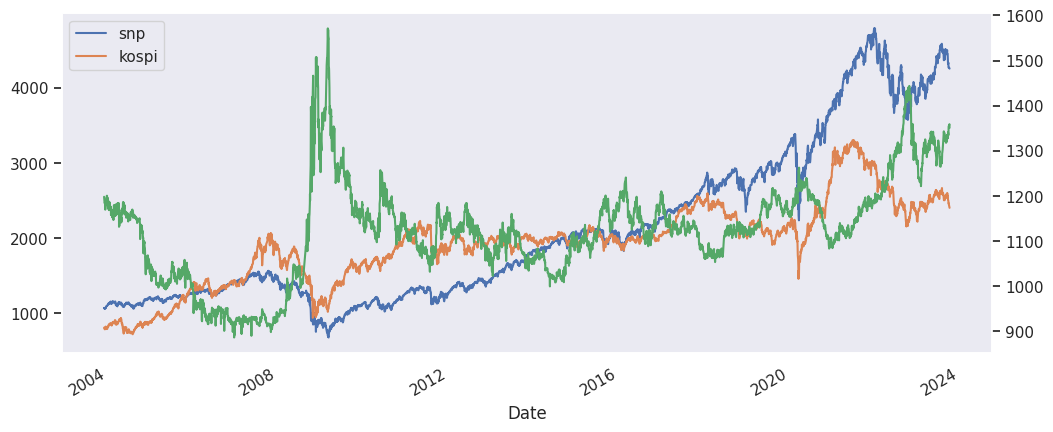

In [ ]:
ax1 = df[['snp', 'kospi']].plot(figsize=(12,5))
ax1.grid(False)
df.krw.plot(secondary_y=True, ax=ax1)
ax1.right_ax.grid(False)

In [ ]:
df.shape

(4500, 3)

In [ ]:
### pandas dataframe의 함수를 활용
## df; df.loc; df.iloc
# df.loc[df.KOSPI>0, 1]
# df.loc[df.KOSPI<0, -1]
# df.iteritems OR
# df.iterrows

In [ ]:
ret = df.pct_change().dropna() * 250
ret.head()

,krw,snp,kospi
Date,,,
2003-12-02,-0.709284,-0.817665,0.120764
2003-12-03,-0.523013,-0.442992,0.173314
2003-12-04,-0.503150,1.171656,-0.992782
2003-12-05,-1.134364,-1.921057,-4.881209
2003-12-08,0.189927,1.837035,-1.459947


In [ ]:
ret['kospi'] = ret.kospi.apply(lambda x: [1, -1][x<0 ])

In [ ]:
ret.head()

,krw,snp,kospi
Date,,,
2003-12-02,-0.709284,-0.817665,1
2003-12-03,-0.523013,-0.442992,1
2003-12-04,-0.503150,1.171656,-1
2003-12-05,-1.134364,-1.921057,-1
2003-12-08,0.189927,1.837035,-1


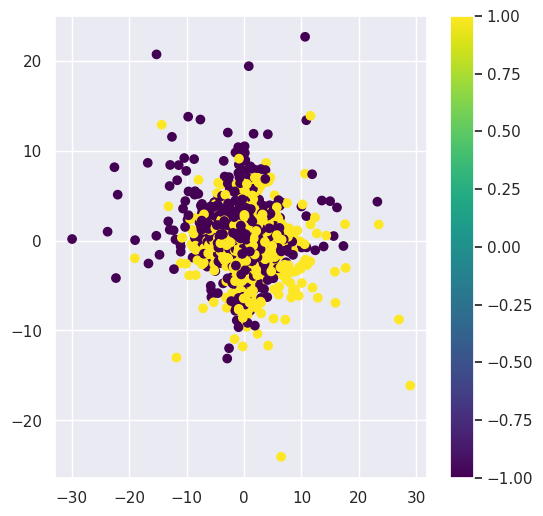

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(ret['snp'], ret['krw'], c=ret.kospi, cmap='viridis')
plt.colorbar();

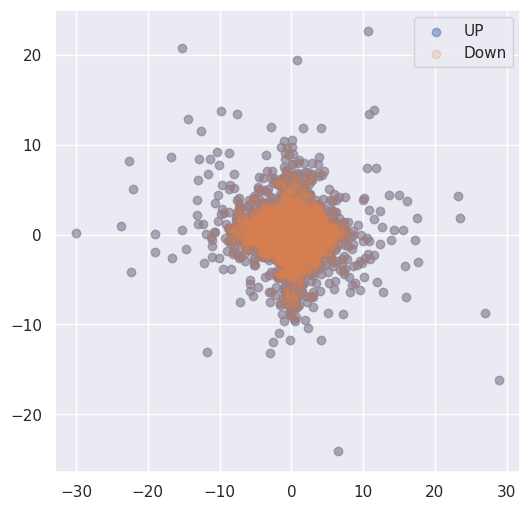

In [ ]:
# for your reference for plotting using seaborn
plt.figure(figsize=(6,6))
plt.scatter(ret['snp'].groupby(ret['kospi'] == 1).ffill(), ret['krw'].groupby(ret['kospi'] == 1).ffill(), alpha=0.5, label='UP')
plt.scatter(ret['snp'].groupby(ret.kospi == -1).ffill(), ret['krw'].groupby(ret['kospi'] == -1).ffill(), alpha=0.2, label='Down')
plt.legend();

In [ ]:
## Generate Tree Instances

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(ret[['krw', 'snp']], ret[['kospi']], test_size=0.25, random_state=33)

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(Xtrain, ytrain)

DecisionTreeClassifier(max_depth=3)

In [ ]:
from sklearn.metrics import *

In [ ]:
dir(sklearn.metrics)

In [ ]:
from sklearn.metrics import accuracy_score

yhat = clf.predict(Xtest)
accuracy_score(yhat, ytest)


0.5838983050847457

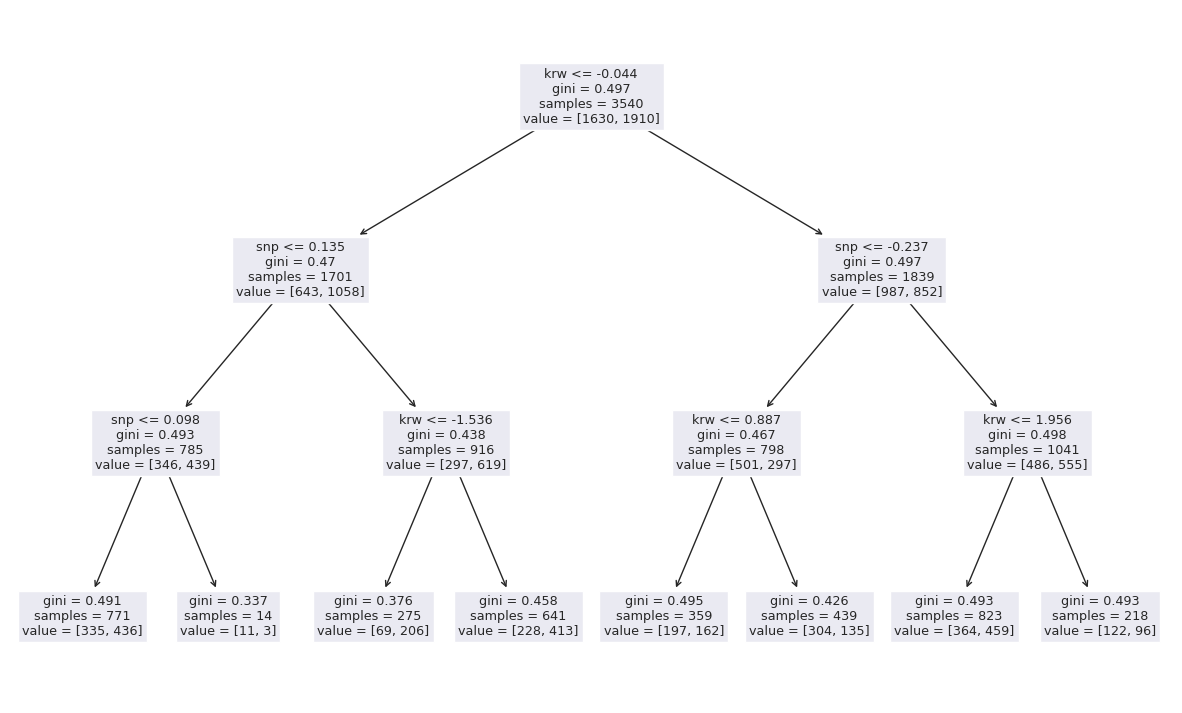

In [ ]:
from sklearn import tree

plt.figure(figsize=(15,9))
tree.plot_tree(clf, feature_names=['krw', 'snp']);

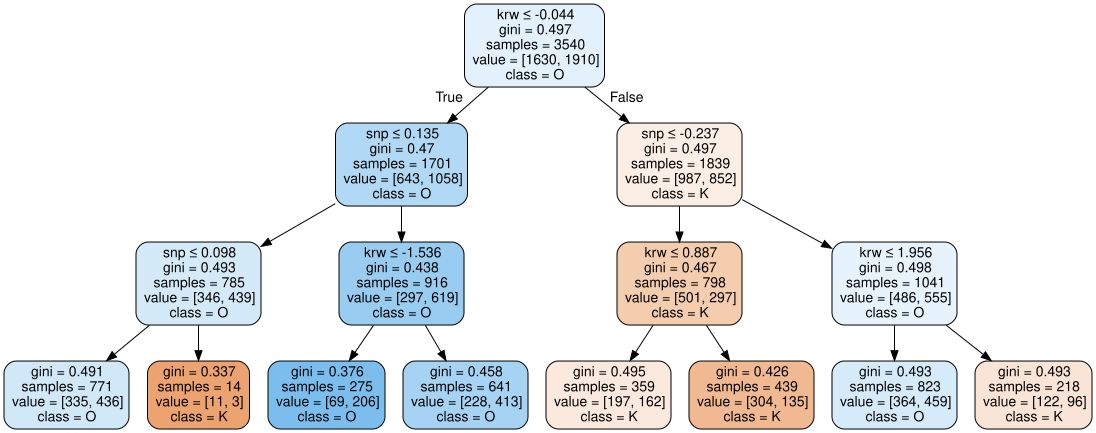

<Figure size 600x600 with 0 Axes>

In [ ]:
from sklearn import tree
import graphviz

dot_data = tree.export_graphviz(clf,
                  feature_names=["krw", 'snp'],
                  class_names='KOSPI',
                  filled=True, rounded=True,
                  special_characters=True,
                   out_file=None,
                           )

plt.figure(figsize=(6,6))
graph = graphviz.Source(dot_data)
graph

In [ ]:
from sklearn.model_selection import GridSearchCV



In [ ]:
## Is GridSearch improve the accuracy_score?

from sklearn.model_selection import GridSearchCV

params = {'max_leaf_nodes':list(np.arange(2,20)), 'min_samples_leaf':[2,3,4,5]}
#params = {'max_leaf_nodes':list(np.arange(2,20))}


clf_grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)

In [ ]:
clf_grid.fit(Xtrain, ytrain)
yhat_grid = clf_grid.predict(Xtest.values)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
accuracy_score(yhat_grid, ytest)

0.5847457627118644

In [ ]:
clf_grid.best_estimator_

DecisionTreeClassifier(max_leaf_nodes=9, min_samples_leaf=2)